In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("all_cars_datset_final.csv")
df


,Brand,Car Name,Price,Rating,Safety,Mileage,Power (BHP),FY2024(sales)
0,Maruti Suzuki,Maruti Brezza,Rs. 8.69 Lakh,4.5/5,4 Star Safety,17-25 kmpl,87-102 bhp,"1,69,897"
1,Maruti Suzuki,Maruti Fronx,Rs. 7.54 Lakh,4.6/5,3 Star Safety,20-28 kmpl,76-99 bhp,"1,34,735"
2,Maruti Suzuki,Maruti Swift,Rs. 6.49 Lakh,4.6/5,2 Star Safety,24-32 kmpl,69-80 bhp,"1,95,321"
3,Maruti Suzuki,Maruti Dzire,Rs. 6.84 Lakh,4.7/5,5 Star Safety,24-33 kmpl,69-80 bhp,"1,64,517"
4,Maruti Suzuki,Maruti Baleno,Rs. 6.70 Lakh,4.5/5,4 Star Safety,22-30 kmpl,76-88 bhp,"1,95,607"
...,...,...,...,...,...,...,...,...
243,McLaren,McLaren 720S,Rs. 4.65 Crore,4.8/5,5 Star Safety,8 kmpl,711 bhp,18
244,McLaren,McLaren GT,Rs. 3.72 Crore,4.5/5,5 Star Safety,7 kmpl,612 bhp,12
245,Lotus,Lotus Eletre,Rs. 2.55 Crore,4.5/5,5 Star Safety,NaN,NaN,250
246,Lotus,Lotus Emira,Rs. 3.22 Crore,05-May,5 Star Safety,NaN,360 bhp,40


In [2]:

print(df.head())


print(df.shape)

print(df.columns)


print(df.info())


print(df.describe())



           Brand       Car Name          Price Rating         Safety  \
0  Maruti Suzuki  Maruti Brezza  Rs. 8.69 Lakh  4.5/5  4 Star Safety   
1  Maruti Suzuki   Maruti Fronx  Rs. 7.54 Lakh  4.6/5  3 Star Safety   
2  Maruti Suzuki   Maruti Swift  Rs. 6.49 Lakh  4.6/5  2 Star Safety   
3  Maruti Suzuki   Maruti Dzire  Rs. 6.84 Lakh  4.7/5  5 Star Safety   
4  Maruti Suzuki  Maruti Baleno  Rs. 6.70 Lakh  4.5/5  4 Star Safety   

      Mileage Power (BHP) FY2024(sales)  
0  17-25 kmpl  87-102 bhp      1,69,897  
1  20-28 kmpl   76-99 bhp      1,34,735  
2  24-32 kmpl   69-80 bhp      1,95,321  
3  24-33 kmpl   69-80 bhp      1,64,517  
4  22-30 kmpl   76-88 bhp      1,95,607  
(248, 8)
Index(['Brand', 'Car Name', 'Price', 'Rating', 'Safety', 'Mileage',
       'Power (BHP)', 'FY2024(sales)'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         ---------

In [3]:
# Har column me kitni missing values hain
print(df.isnull().sum())


Brand              0
Car Name           0
Price              0
Rating             6
Safety            49
Mileage          119
Power (BHP)       39
FY2024(sales)    136
dtype: int64


In [4]:
print(df.duplicated().sum())
# for duplicate rows


0


# To handle null values

In [5]:
# You can delete them
df = df.dropna()
df = df.drop_duplicates()



In [6]:
# Keep only values that contain "/5"
df = df[df['Rating'].str.contains("/5", na=False)]


# Step 1: Sirf numeric ratings filter karo

In [7]:
# Keep only values that contain "/5"
df = df[df['Rating'].str.contains("/5", na=False)]


# Step 2: "/5" remove karke float me convert karo

In [8]:
df['Rating_clean'] = df['Rating'].str.replace("/5", "", regex=False)
df['Rating_clean'] = pd.to_numeric(df['Rating_clean'], errors='coerce')
# Yahan errors='coerce' ka matlab → agar koi non-numeric value bachi hogi toh usko NaN bana dega instead of crashing

# Step 3: Missing values ko handle karo

In [9]:
# Replace missing ratings with average rating
df['Rating_clean'] = df['Rating_clean'].fillna(df['Rating_clean'].mean())


Rating	Rating_clean 
"4.5/5"	4.5
"3.8/5"	3.8
"None"	(filled with avg, e.g. 4.2)


In [10]:
df['Price_clean'] = df['Price'].str.replace("Rs. ", "", regex=False)
df['Price_clean'] = df['Price_clean'].str.replace(",", "", regex=False)


In [11]:
def convert_price(price):
    if isinstance(price, str):
        if "Lakh" in price:
            return float(price.replace(" Lakh", ""))     # already in Lakhs
        elif "Crore" in price:
            return float(price.replace(" Crore", "")) * 100   # 1 Crore = 100 Lakhs
    return None

df['Price_clean'] = df['Price_clean'].apply(convert_price)


In [12]:
df['Price_clean'] = df['Price_clean'].fillna(df['Price_clean'].mean())


In [13]:
def clean_mileage(val):
    if isinstance(val, str):
        val = val.replace(" kmpl", "").replace(" km/kg", "")
        if "-" in val:
            parts = val.split("-")
            return (float(parts[0]) + float(parts[1])) / 2
        else:
            try:
                return float(val)
            except:
                return None
    return None

df["Mileage_clean"] = df["Mileage"].apply(clean_mileage)


In [14]:
def clean_bhp(val):
    if isinstance(val, str):
        val = val.replace(" bhp", "")
        if "-" in val:
            parts = val.split("-")
            return (float(parts[0]) + float(parts[1])) / 2
        else:
            try:
                return float(val)
            except:
                return None
    return None

df["BHP_clean"] = df["Power (BHP)"].apply(clean_bhp)


In [15]:
df["Mileage_clean"] = df["Mileage_clean"].fillna(df["Mileage_clean"].mean())
df["BHP_clean"] = df["BHP_clean"].fillna(df["BHP_clean"].mean())


In [16]:
df["FY2024(sales)"] = df["FY2024(sales)"].str.replace(",", "")


In [17]:
df["FY2024(sales)"] = df["FY2024(sales)"].astype(int)


In [18]:
df["FY2024(sales)"].head()

0    169897
1    134735
2    195321
3    164517
4    195607
Name: FY2024(sales), dtype: int64

In [19]:
df["FY2024(sales)"] = df["FY2024(sales)"].fillna(df["FY2024(sales)"].mean())


In [20]:
df["FY2024(sales)"].isna().sum()

0

In [21]:
sales_by_brand = df.groupby('Brand')['FY2024(sales)'].sum().sort_values(ascending=False).head(10).reset_index()


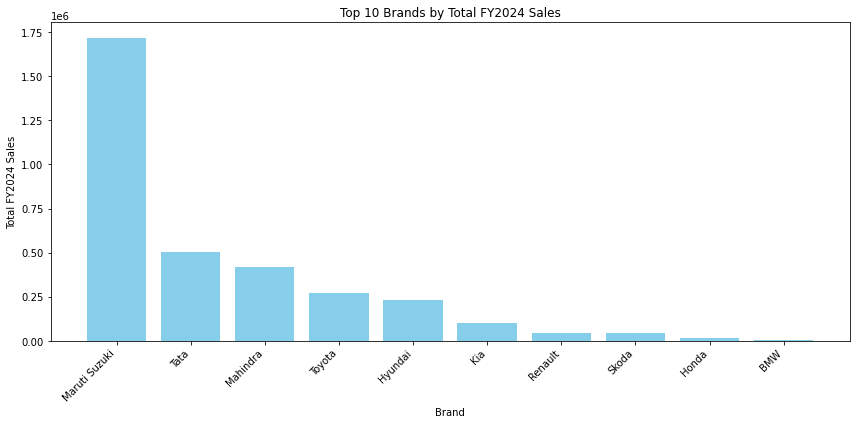

In [27]:
# Plotting Top 10 Brands by Sales

plt.figure(figsize=(12, 6))
plt.bar(sales_by_brand['Brand'], sales_by_brand['FY2024(sales)'], color='skyblue')
plt.xlabel('Brand')
plt.ylabel('Total FY2024 Sales')
plt.title('Top 10 Brands by Total FY2024 Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# plt.savefig('top_10_brands_by_sales.png')
plt.show()
# print("Top 10 Sales analysis plot generated.")



In [28]:
# Top 10 Safest Cars
top_safest_cars = df.sort_values(by=['Safety', 'Rating'], ascending=False).head(10).reset_index(drop=True)

# Saving the output to a CSV file
top_safest_cars_csv = top_safest_cars[['Brand', 'Car Name', 'Safety', 'Rating', 'Price']]
top_safest_cars_csv.to_csv('top_10_safest_cars.csv', index=False)
print("Top 10 Safest Cars data saved to CSV.")


Top 10 Safest Cars data saved to CSV.


/tmp/ipykernel_15423/4101360305.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


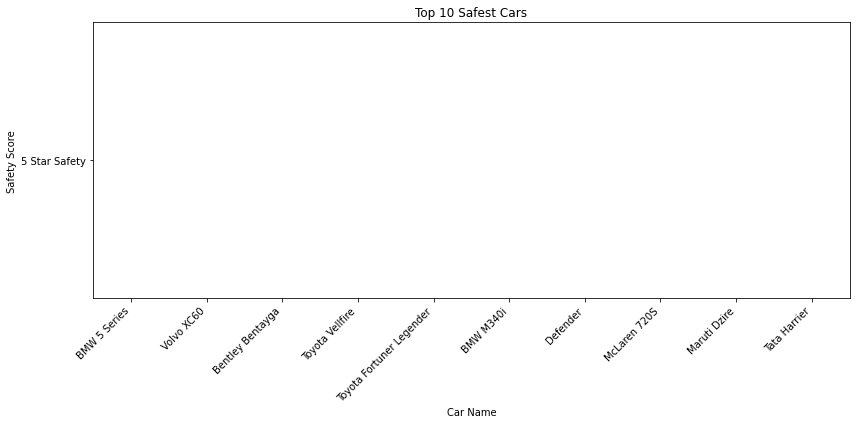

In [29]:

plt.figure(figsize=(12,6))

sns.barplot(
    x='Car Name', 
    y='Safety', 
    data=top_safest_cars, 
    palette='viridis'
)

plt.xlabel('Car Name')
plt.ylabel('Safety Score')
plt.title('Top 10 Safest Cars')
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()

plt.show()
